# 라이브러리 호출

In [46]:
# 98 Page
# 데이터 구성:Series, DataFrame
import pandas as pd
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib
# export_graphviz: 나무 구조 생성 및 저장
from sklearn.tree import export_graphviz
# graphviz : 나무 구조 시각화  (.dot 확장자 파일 불러오기 등)
import graphviz
# 데이터 분할:train, test
from sklearn.model_selection import train_test_split
# 예측/회귀 Decision Tree
from sklearn.tree import DecisionTreeRegressor
# 최적 모델, 파라미터 탐색
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor


plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

pd.options.mode.chained_assignment = None

sns.set_palette('BrBG')
pal = sns.color_palette('BrBG')
sns.color_palette('BrBG')

[(0.6313725490196078, 0.3951557093425605, 0.09573241061130335),
 (0.8572856593617839, 0.7257977700884274, 0.4471357170319107),
 (0.9636293733179546, 0.9237985390234525, 0.8185313341022683),
 (0.8299115724721262, 0.9294886582083814, 0.9152633602460593),
 (0.4615916955017304, 0.7748558246828146, 0.7299500192233758),
 (0.0878892733564014, 0.479123414071511, 0.44775086505190315)]

In [47]:
df = pd.read_csv("bat_process.csv" ,encoding = "cp949")

In [48]:
df

,lot_id,tray_id,cell_id,dt_start,judge,rta1_cell_no,rta1_box_col,rta1_box_row,rta1_box_dan,hta1_box_col,...,sa3_box_row,sa3_box_dan,socv3_ocv,ocv2_deltaocv,ocv1_deltaocv,m1_thick,m1_voltage,m1_res_ac,m1_mv,m1_voltage_an
0,LOT-100,TRAY-1023,CELL-10747,01SEP24:10:01:25,양품,10,08열,33연,08단,03열,...,37연,04단,3759.3,5.0,6.8,4718.0,37583.0,94.0,565.0,164.0
1,LOT-100,TRAY-1023,CELL-10748,01SEP24:10:01:25,양품,7,08열,33연,08단,03열,...,37연,04단,3758.4,5.0,6.8,4718.0,37574.0,94.0,565.0,73.0
2,LOT-100,TRAY-1023,CELL-10749,01SEP24:10:01:25,양품,19,08열,33연,08단,03열,...,37연,04단,3759.0,5.1,6.9,4700.0,37579.0,91.0,585.0,-57.0
3,LOT-100,TRAY-1023,CELL-10750,01SEP24:10:01:25,양품,24,08열,33연,08단,03열,...,37연,04단,3759.5,5.1,6.9,4688.0,37583.0,93.0,606.0,99.0
4,LOT-100,TRAY-1023,CELL-10751,01SEP24:10:01:25,양품,17,08열,33연,08단,03열,...,37연,04단,3758.2,5.0,6.8,4696.0,37570.0,91.0,605.0,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38590,LOT-144,TRAY-2791,CELL-53649,17SEP24:18:33:15,양품,16,08열,21연,03단,02열,...,16연,13단,3759.2,5.3,7.2,4745.0,37583.0,94.0,643.0,-35.0
38591,LOT-144,TRAY-2791,CELL-53650,17SEP24:18:33:15,양품,14,08열,21연,03단,02열,...,16연,13단,3759.2,5.3,7.1,4746.0,37583.0,94.0,620.0,89.0
38592,LOT-144,TRAY-2791,CELL-53651,17SEP24:18:33:15,양품,2,08열,21연,03단,02열,...,16연,13단,3760.3,5.2,7.0,4782.0,37595.0,92.0,597.0,-23.0
38593,LOT-144,TRAY-2791,CELL-54355,17SEP24:18:33:15,양품,15,08열,21연,03단,02열,...,16연,13단,3760.0,5.3,7.0,4751.0,37590.0,95.0,620.0,3.0


In [49]:
# 'judge' 컬럼을 사용하여 '불량'인 경우 1, '양품'인 경우 0으로 변환
df['is_defect'] = df['judge'].apply(lambda x: 1 if x == '불량' else 0)

# 트레이별로 그룹화하고 불량률 계산
# 각 트레이의 전체 셀 수와 불량 셀 수를 계산
tray_grouped = df.groupby('tray_id').agg(
    total_cells=('cell_id', 'count'),
    defect_cells=('is_defect', 'sum')
).reset_index()

# 불량률 계산 (불량 셀 수 / 전체 셀 수)
tray_grouped['defect_rate'] = tray_grouped['defect_cells'] / tray_grouped['total_cells']

# total_cells와 defect_cells 컬럼 제거
tray_stats = tray_grouped[['tray_id', 'defect_rate']]

print("트레이별 불량률이 계산된 tray_stats 데이터프레임 (total_cells, defect_cells 제외):")
display(tray_stats.head())

트레이별 불량률이 계산된 tray_stats 데이터프레임 (total_cells, defect_cells 제외):


,tray_id,defect_rate
0,TRAY-1002,0.0
1,TRAY-1003,0.0
2,TRAY-1004,0.0
3,TRAY-1005,0.0
4,TRAY-1006,0.0


In [50]:
df_raw = df[['tray_id','rta1_box_col',
'rta1_box_row',
'rta1_box_dan',
'hta1_box_col',
'hta1_box_row',
'hta1_box_dan',
'rta2_box_col',
'rta2_box_row',
'rta2_box_dan'
]]

In [51]:
df_raw = pd.merge(df_raw, tray_stats, on='tray_id', how='inner')

In [52]:
df_raw

,tray_id,rta1_box_col,rta1_box_row,rta1_box_dan,hta1_box_col,hta1_box_row,hta1_box_dan,rta2_box_col,rta2_box_row,rta2_box_dan,defect_rate
0,TRAY-1023,08열,33연,08단,03열,25연,03단,04열,64연,06단,0.0
1,TRAY-1023,08열,33연,08단,03열,25연,03단,04열,64연,06단,0.0
2,TRAY-1023,08열,33연,08단,03열,25연,03단,04열,64연,06단,0.0
3,TRAY-1023,08열,33연,08단,03열,25연,03단,04열,64연,06단,0.0
4,TRAY-1023,08열,33연,08단,03열,25연,03단,04열,64연,06단,0.0
...,...,...,...,...,...,...,...,...,...,...,...
38590,TRAY-2791,08열,21연,03단,02열,23연,06단,03열,42연,06단,0.2
38591,TRAY-2791,08열,21연,03단,02열,23연,06단,03열,42연,06단,0.2
38592,TRAY-2791,08열,21연,03단,02열,23연,06단,03열,42연,06단,0.2
38593,TRAY-2791,08열,21연,03단,02열,23연,06단,03열,42연,06단,0.2


In [53]:
df_raw

,tray_id,rta1_box_col,rta1_box_row,rta1_box_dan,hta1_box_col,hta1_box_row,hta1_box_dan,rta2_box_col,rta2_box_row,rta2_box_dan,defect_rate
0,TRAY-1023,08열,33연,08단,03열,25연,03단,04열,64연,06단,0.0
1,TRAY-1023,08열,33연,08단,03열,25연,03단,04열,64연,06단,0.0
2,TRAY-1023,08열,33연,08단,03열,25연,03단,04열,64연,06단,0.0
3,TRAY-1023,08열,33연,08단,03열,25연,03단,04열,64연,06단,0.0
4,TRAY-1023,08열,33연,08단,03열,25연,03단,04열,64연,06단,0.0
...,...,...,...,...,...,...,...,...,...,...,...
38590,TRAY-2791,08열,21연,03단,02열,23연,06단,03열,42연,06단,0.2
38591,TRAY-2791,08열,21연,03단,02열,23연,06단,03열,42연,06단,0.2
38592,TRAY-2791,08열,21연,03단,02열,23연,06단,03열,42연,06단,0.2
38593,TRAY-2791,08열,21연,03단,02열,23연,06단,03열,42연,06단,0.2


In [54]:
df_raw = df_raw.drop('tray_id',axis=1)

In [55]:
df_raw

,rta1_box_col,rta1_box_row,rta1_box_dan,hta1_box_col,hta1_box_row,hta1_box_dan,rta2_box_col,rta2_box_row,rta2_box_dan,defect_rate
0,08열,33연,08단,03열,25연,03단,04열,64연,06단,0.0
1,08열,33연,08단,03열,25연,03단,04열,64연,06단,0.0
2,08열,33연,08단,03열,25연,03단,04열,64연,06단,0.0
3,08열,33연,08단,03열,25연,03단,04열,64연,06단,0.0
4,08열,33연,08단,03열,25연,03단,04열,64연,06단,0.0
...,...,...,...,...,...,...,...,...,...,...
38590,08열,21연,03단,02열,23연,06단,03열,42연,06단,0.2
38591,08열,21연,03단,02열,23연,06단,03열,42연,06단,0.2
38592,08열,21연,03단,02열,23연,06단,03열,42연,06단,0.2
38593,08열,21연,03단,02열,23연,06단,03열,42연,06단,0.2


In [56]:
# 목표 변수(y)와 설명 변수(X)를 설정합니다.
df_y = df_raw['defect_rate']
df_x_raw = df_raw.drop('defect_rate', axis=1)

# 범주형 데이터를 원-핫 인코딩하여 숫자형으로 변환합니다.
df_x = pd.get_dummies(df_x_raw)

# 생성된 데이터프레임 확인
print("목표 변수 (df_y):")
display(df_y.head())
print("\n설명 변수 (df_x):")
display(df_x.head())

목표 변수 (df_y):


0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: defect_rate, dtype: float64


설명 변수 (df_x):


,rta1_box_col_01열,rta1_box_col_02열,rta1_box_col_03열,rta1_box_col_04열,rta1_box_col_05열,rta1_box_col_06열,rta1_box_col_07열,rta1_box_col_08열,rta1_box_row_01연,rta1_box_row_02연,...,rta2_box_dan_02단,rta2_box_dan_03단,rta2_box_dan_04단,rta2_box_dan_05단,rta2_box_dan_06단,rta2_box_dan_07단,rta2_box_dan_08단,rta2_box_dan_09단,rta2_box_dan_10단,rta2_box_dan_11단
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
1,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0


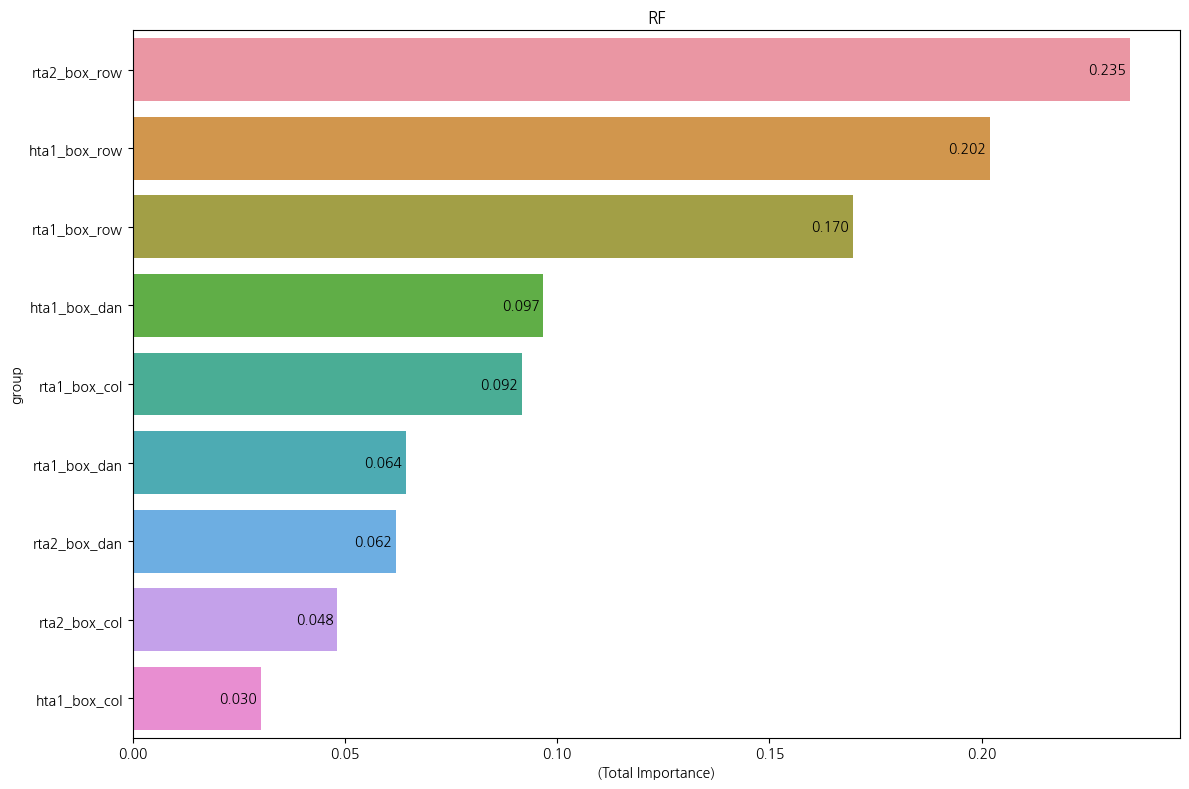

group별 중요도:


,feature_group,total_importance
0,rta2_box_row,0.234989
1,hta1_box_row,0.202022
2,rta1_box_row,0.169694
3,hta1_box_dan,0.096794
4,rta1_box_col,0.091633
5,rta1_box_dan,0.064302
6,rta2_box_dan,0.061994
7,rta2_box_col,0.048271
8,hta1_box_col,0.030301


In [69]:
# 데이터 분할 (CELL 14에도 있지만, 모델 훈련 전 단계이므로 여기서 수행)
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_x, df_y,
                                                                test_size = 0.3, random_state = 42)

# 랜덤 포레스트 모델 생성 및 훈련
# n_jobs=-1: 모든 CPU 코어를 사용하여 학습 속도 향상
rf_model_full = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model_full.fit(df_train_x, df_train_y)

# 변수 중요도 추출
importances = rf_model_full.feature_importances_
features = df_train_x.columns

# 변수 중요도를 데이터프레임으로 생성
importance_df = pd.DataFrame({'feature': features, 'importance': importances})

# 원-핫 인코딩된 컬럼 이름에서 원래 변수 이름(그룹)을 추출하는 함수
# 예: 'rta1_box_col_01열' -> 'rta1_box_col'
def get_original_feature(col_name):
    parts = col_name.split('_')
    return '_'.join(parts[:-1])

importance_df['feature_group'] = importance_df['feature'].apply(get_original_feature)

# 원래 group을 기준으로 중요도 합산
aggregated_importances = importance_df.groupby('feature_group')['importance'].sum().sort_values(ascending=False)

# 시각화를 위해 데이터프레임으로 변환
aggregated_importances_df = aggregated_importances.reset_index()
aggregated_importances_df.columns = ['feature_group', 'total_importance']


# 그룹화된 변수 중요도 시각화
plt.figure(figsize=(12, 8))
# ax 객체를 변수로 받습니다.
ax = sns.barplot(x='total_importance', y='feature_group', data=aggregated_importances_df)

# --- 이 부분이 추가된 부분 ---
# ax.bar_label을 사용하여 막대 내부에 값 표시
ax.bar_label(
    ax.containers[0],
    fmt='%.3f',       # 소수점 3자리까지 포맷팅
    padding=-30,      # 막대 끝에서 안쪽으로 30포인트만큼 이동
    color='black',    # 텍스트 색상
    fontsize=10       # 텍스트 폰트 크기
)
# --- 여기까지 ---

plt.title('RF')
plt.xlabel('(Total Importance)')
plt.ylabel('group')

# 텍스트가 잘 보이도록 x축의 오른쪽 여백을 조금 더 확보합니다.
# (이미 막대 안에 넣었지만, 값이 0에 가까운 경우를 대비)
ax.set_xlim(right=aggregated_importances_df['total_importance'].max() * 1.05)

plt.tight_layout()
plt.show()

# 그룹화된 변수 중요도 표 출력
print("group별 중요도:")
display(aggregated_importances_df)

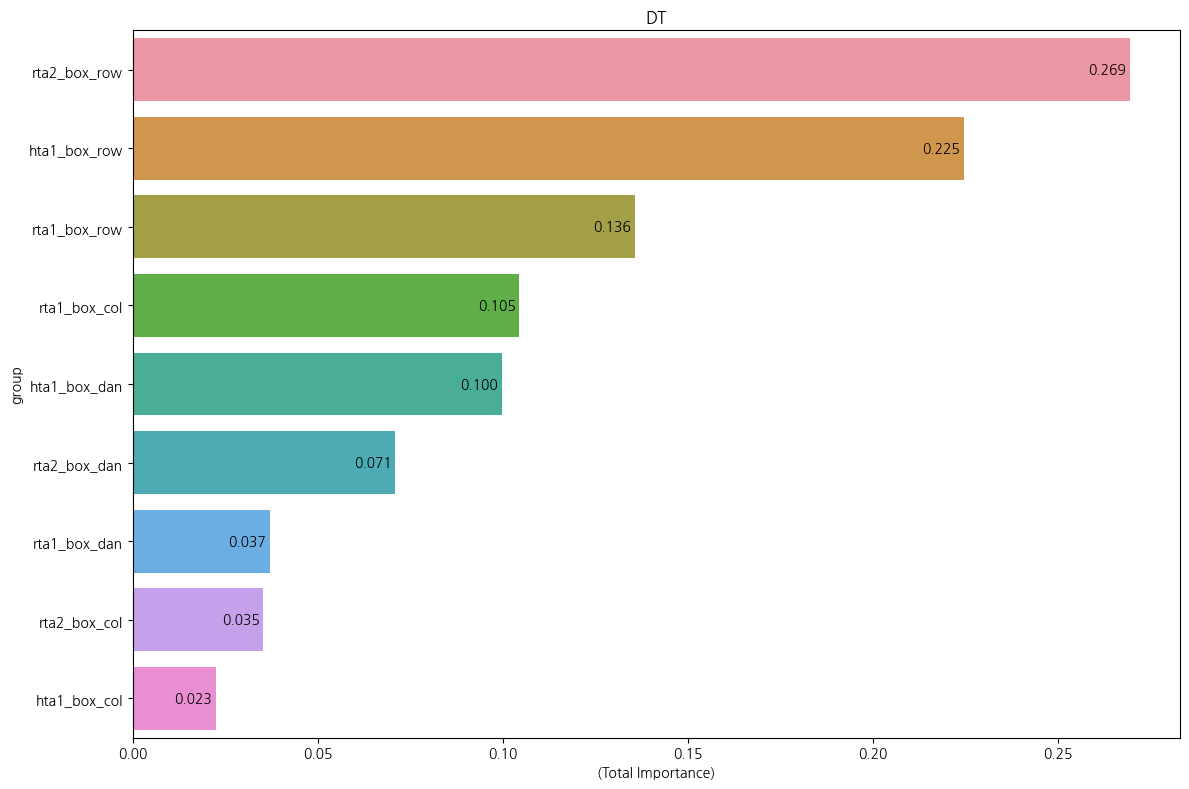

group별 중요도:


,feature_group,total_importance
0,rta2_box_row,0.269450
1,hta1_box_row,0.224658
2,rta1_box_row,0.135748
3,rta1_box_col,0.104514
4,hta1_box_dan,0.099776
5,rta2_box_dan,0.070987
6,rta1_box_dan,0.037013
7,rta2_box_col,0.035326
8,hta1_box_col,0.022528


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor  # 랜덤 포레스트 대신 의사결정나무 임포트
from IPython.display import display

# (데이터프레임 df_x, df_y가 이미 정의되어 있다고 가정합니다)

# 데이터 분할
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_x, df_y,
                                                                test_size = 0.3, random_state = 42)

# 의사결정나무 모델 생성 및 훈련
# RandomForestRegressor -> DecisionTreeRegressor로 변경
# n_estimators, n_jobs 파라미터는 의사결정나무에 없으므로 제거
dt_model_full = DecisionTreeRegressor(random_state=1234)
dt_model_full.fit(df_train_x, df_train_y)

# 변수 중요도 추출
importances = dt_model_full.feature_importances_ # 모델 변수명 변경 (rf_model_full -> dt_model_full)
features = df_train_x.columns

# 변수 중요도를 데이터프레임으로 생성
importance_df = pd.DataFrame({'feature': features, 'importance': importances})

# 원-핫 인코딩된 컬럼 이름에서 원래 변수 이름(그룹)을 추출하는 함수
# 예: 'rta1_box_col_01열' -> 'rta1_box_col'
def get_original_feature(col_name):
    parts = col_name.split('_')
    # 마지막 부분('_' 뒤의 숫자)을 제외하고 합칩니다.
    if len(parts) > 1:
        return '_'.join(parts[:-1])
    else:
        return col_name

importance_df['feature_group'] = importance_df['feature'].apply(get_original_feature)

# 원래 Group을 기준으로 중요도 합산
aggregated_importances = importance_df.groupby('feature_group')['importance'].sum().sort_values(ascending=False)

# 시각화를 위해 데이터프레임으로 변환
aggregated_importances_df = aggregated_importances.reset_index()
aggregated_importances_df.columns = ['feature_group', 'total_importance']

# 그룹화된 변수 중요도 시각화
plt.figure(figsize=(12, 8))
# ax 객체를 변수로 받습니다.
ax = sns.barplot(x='total_importance', y='feature_group', data=aggregated_importances_df)

# --- 이 부분이 추가된 부분 ---
# ax.bar_label을 사용하여 막대 내부에 값 표시
ax.bar_label(
    ax.containers[0],
    fmt='%.3f',       # 소수점 3자리까지 포맷팅
    padding=-30,      # 막대 끝에서 안쪽으로 30포인트만큼 이동
    color='black',    # 텍스트 색상
    fontsize=10       # 텍스트 폰트 크기
)
# --- 여기까지 ---

plt.title('DT')
plt.xlabel('(Total Importance)')
plt.ylabel('group')

# 텍스트가 잘 보이도록 x축의 오른쪽 여백을 조금 더 확보합니다.
# (이미 막대 안에 넣었지만, 값이 0에 가까운 경우를 대비)
ax.set_xlim(right=aggregated_importances_df['total_importance'].max() * 1.05)

plt.tight_layout()
plt.show()

# 그룹화된 변수 중요도 표 출력
print("group별 중요도:")
display(aggregated_importances_df)